<a href="https://colab.research.google.com/github/tinawanggg/Wang_DSPN_S26/blob/master/book/exercises/17_regularized-regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 17: Regularized regression

This homework assignment is designed to give you an intuition as an interesting property of regularization in the context of ultra-high dimensional statistical problems.

You won't need to load in any data for this homework.

---
## 1. Simulating & visualizing data (2 points)

We are going to be looking at what happens in the context where $p>n$. In order to have total control over our data, we will use simulations for this homework. First, we will need to load the `glmnet`, `tidyverse`, and `ggplot2` libraries for this assignment.


In [2]:
# WRITE YOUR CODE HERE
install.packages("glmnet", dependencies = TRUE)
library(glmnet)
library(tidyverse)
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘RcppEigen’


Loading required package: Matrix

Loaded glmnet 4.1-10

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::expand() masks Matrix::expand()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ tidyr::pack()   masks Matrix::pack()
✖ tidyr::unpack() masks Matrix::unpack()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


We are going to generate a data set with complex structure and try to recover it using polynomial models. For simplicity sake, use the following code to produce a response variable, $y$ that has complex structure.

*Hint: Look up what a cosine function looks like if you need a reminder.*

In [3]:
# Generate data
set.seed(121)
sigma_noise = .5
x=seq(-9,9,by=.18)
n=length(x)
y = 0.1*x + cos(x) + cos(x/20)+rnorm(n,sd=sigma_noise)

(a) Break the data into a training set (n=50) and test set (n=51) using the `sample` function to randomly select subsets of x and y.  Make a separate data frame for the training and test data.

(**Note**: *Do not* just take the first 50 observations to be the training set and last 51 observations to be the test set.)

In [7]:
# WRITE YOUR CODE HERE
set.seed(121)
train_idx <- sample(1:n, size = 50, replace = FALSE)
test_idx  <- setdiff(1:n, train_idx)

train_df <- data.frame(x = x[train_idx], y = y[train_idx])
test_df  <- data.frame(x = x[test_idx],  y = y[test_idx])

(b) Plot the training data ($x$ \& $y$). Describe the relationship that you see in the training data.

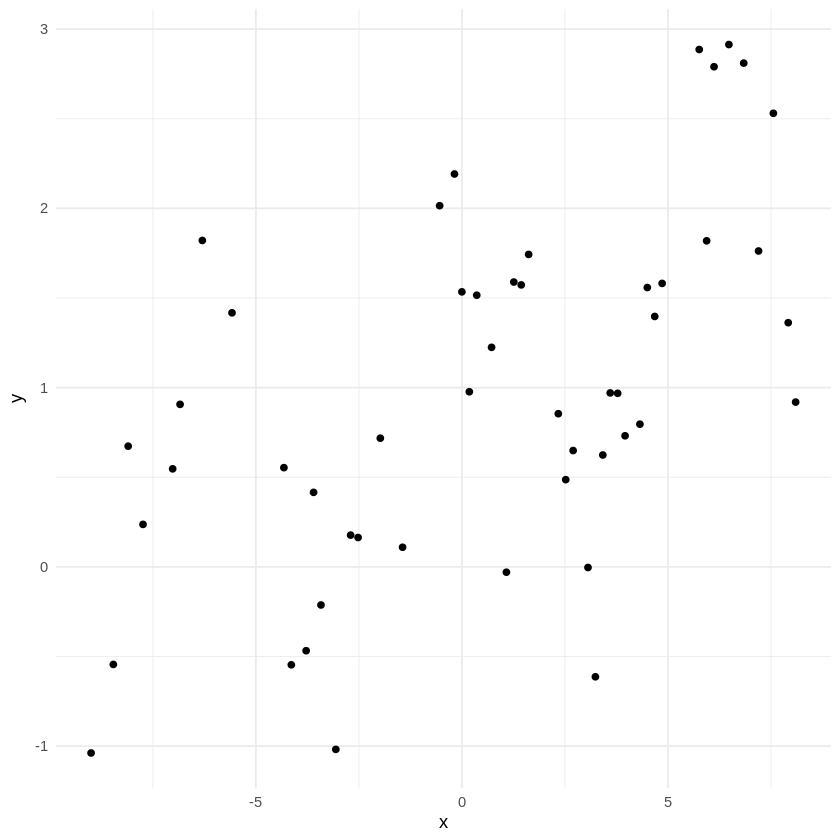

In [9]:
# WRITE YOUR CODE HERE
ggplot(train_df, aes(x = x, y = y)) +
  geom_point() +
  theme_minimal()

How would you describe the relationship between $x$ and $y$ based on this plot?

> *There doesn't seem to be any clear relationship between x and y on the plot. There might be a very weak positive relationship, but this is not distinct. If observed carefully, you may see a vague oscillating wave pattern from the data points.*
>

---
## 2. Bias-variance tradeoff: polynomial regression (4 points)

Recall that in polynomial regression we increase model complexity by expanding $x$ out to the power $k$ (which we call degree).

$$
Y = \hat{\beta}_0 + \sum_{j=1}^K \hat{\beta}_j X^j
\;=\; \operatorname{poly}(X, K)
$$

(a) Fit a 2nd degree polynomial regression model to the training data. Plot the results.


*Hint: Use the* `help` *function to see how to use the* `stat_smooth()` *and* `poly()` *functions.*

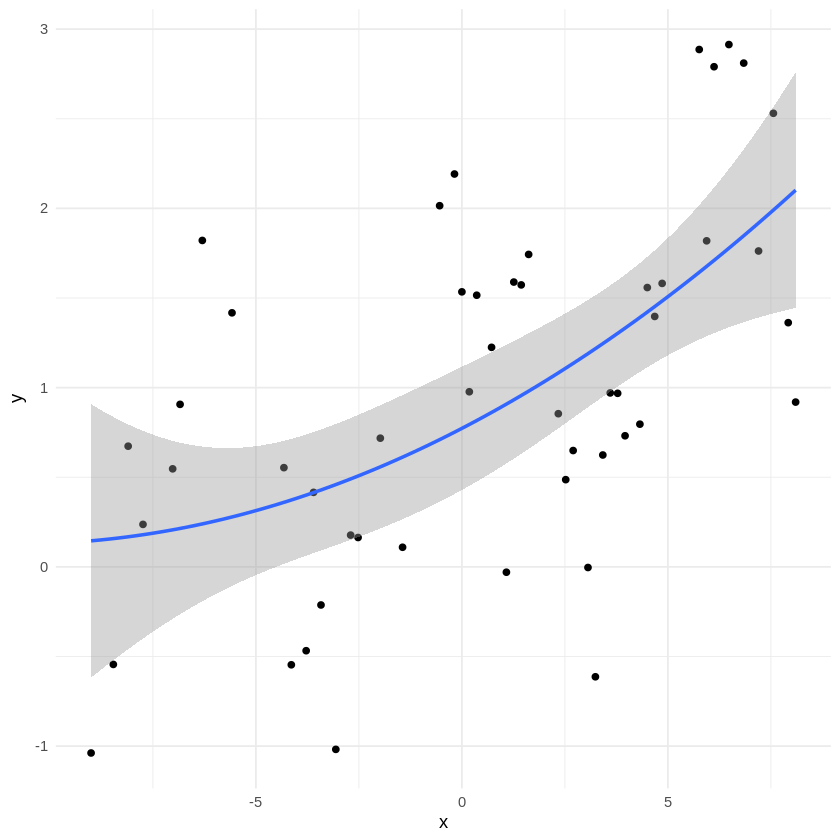

In [11]:
# WRITE YOUR CODE HERE
model_2 <- lm(y ~ poly(x, 2), data = train_df)

ggplot(train_df, aes(x = x, y = y)) +
  geom_point() +
  stat_smooth(method = "lm", formula = y ~ poly(x, 2)) +
  theme_minimal()

How well does this 2nd degree polynomial model qualitatively fit the data? Could it do better?

> *The polynomial model is a poor fit for the data. It only captures the very broad upward trend from left to right, but doesn't capture the oscillating wave structure. Large amounts of data fall above or below the fitted line. Thus, the model could definitely do better. Increasing the degree could allow the curve to better follow the wave pattern rather than just the overall slope.*
>

(b) Fit a 12th degree polynomial to the data. Does this do qualitatively better or worse than the 2nd degree model?

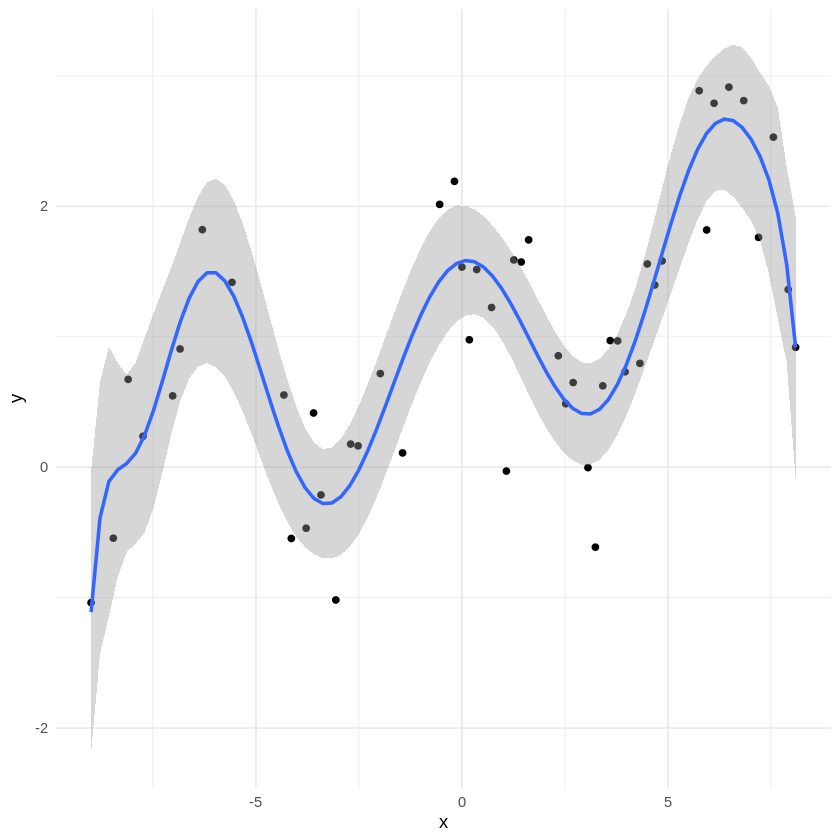

In [12]:
# WRITE YOUR CODE HERE
model_12 <- lm(y ~ poly(x, 12), data = train_df)

ggplot(train_df, aes(x = x, y = y)) +
  geom_point() +
  stat_smooth(method = "lm", formula = y ~ poly(x, 12)) +
  theme_minimal()

> *This is qualitatively much better than the 2nd degree model. The curve now successfully captures the oscillating wave structure, tracing through multiple peaks. It also maintains the slight upward trend from left to right.*
>

(c) Modify the loop below to estimate the bias-variance tradeoff as model complexity (i.e., degree of the polynomial model, $k$) increases from 2 to 50. Use the training data to fit the model and test data to evaluate its predictive accuracy.

Visualize your results by plotting the *median* squared error for the training data and test data as a function of polynomial degree.


(**Note**: We are using median accuracies here because there are often 1 or 2 outlier values in the higher degree polynomial models that can throw off the accuracy estimates).

Warning message in predict.lm(model, newdata = train_df):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(model, newdata = test_df):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(model, newdata = train_df):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(model, newdata = test_df):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(model, newdata = train_df):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(model, newdata = test_df):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(model, newdata = train_df):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(model, newdata = test

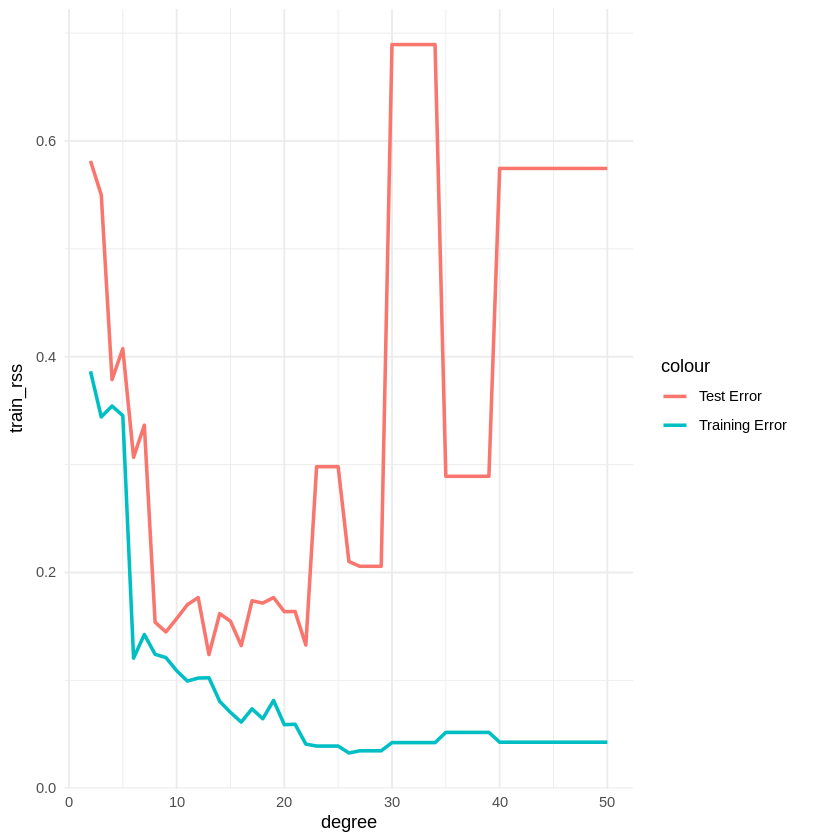

In [34]:
# Now do the variance-bias trade off analysis using regular regression
degree = seq(2,50)

# Need to setup your output vectors
train_rss = matrix(data=NA,nrow=length(degree),ncol=1)
test_rss = matrix(data=NA,nrow=length(degree),ncol=1)

for (k in degree) {
    # WRITE YOUR CODE HERE
    model = lm(y ~ poly(x, k, raw=TRUE), data = train_df)

    train_pred = predict(model, newdata = train_df)
    test_pred  = predict(model, newdata = test_df)

    train_rss[k-1, 1] = median((train_df$y - train_pred)^2)
    test_rss[k-1, 1]  = median((test_df$y - test_pred)^2)
}

# Plot your results here
# WRITE YOUR CODE HERE
results_df <- data.frame(
  degree = degree,
  train_rss = train_rss,
  test_rss = test_rss
)

ggplot(results_df, aes(x = degree)) +
  geom_line(aes(y = train_rss, color = "Training Error"), size = 1) +
  geom_line(aes(y = test_rss, color = "Test Error"), size = 1) +
  theme_minimal()

What do you see as $k$ increase?

> *As k increases, training error decreases while test error first decreases and then increases.*
>

(d) Now copy the code above and let's see what happens when we go beyond $p=n$ (remember, in this case $k=p$). Test polynomial models up to $k=150$. Visualize your results by plotting the *median* squared error for the training data and test data as a function of polynomial degree.

Use the `geom_vline()` function in `ggplot` to draw a vertical line where $k=n$ (here $n$ is the number of observations in the training set). This will make it clear where we cross the threshold for finding *unique* solutions in our data.



In [37]:
# WRITE YOUR CODE HERE
degree = seq(2,150)

# Need to setup your output vectors
train_rss = matrix(data=NA,nrow=length(degree),ncol=1)
test_rss = matrix(data=NA,nrow=length(degree),ncol=1)

for (k in degree) {
    # WRITE YOUR CODE HERE
    model = lm(y ~ poly(x, k), data = train_df)

    train_pred = predict(model, newdata = train_df)
    test_pred  = predict(model, newdata = test_df)

    train_rss[k-1, 1] = median((train_df$y - train_pred)^2)
    test_rss[k-1, 1]  = median((test_df$y - test_pred)^2)
}

# Plot your results here
# WRITE YOUR CODE HERE
results_df = data.frame(
  degree = degree,
  train_rss = train_rss,
  test_rss = test_rss
)

ggplot(results_df, aes(x = degree)) +
  geom_line(aes(y = train_rss, color = "Training Error"), size = 1) +
  geom_line(aes(y = test_rss, color = "Test Error"), size = 1) +
  theme_minimal()

ERROR: Error in poly(x, k): 'degree' must be less than number of unique points


What do you see as $k$ gets larger than $n$?

> *As k gets larger than n, the number of predictors exceeds the number of observations, causing the model to no longer have a unique solution because there are more parameters than data points. This also causes the code to break (because the model cannot fit properly).*
>

---
## 3. Applying regularization to the model fits (2 points)

Repeat the previous bias-variance tradeoff test, going up to $k=150$, but now use ridge regression with a sparsity parameter of $\lambda=0.00005$. Plot your results the same way as last time.

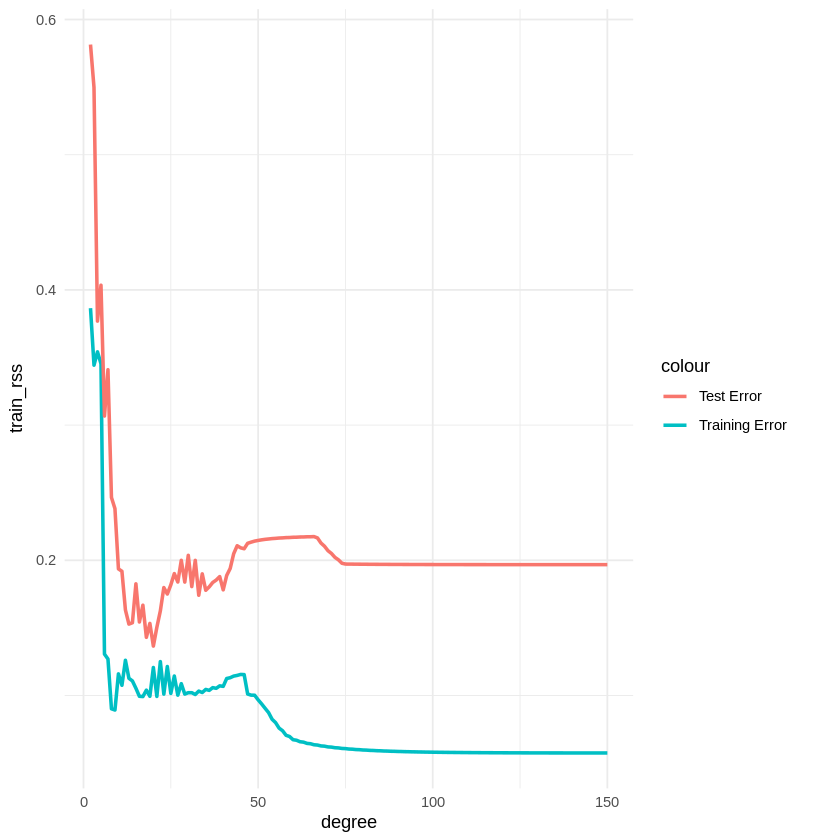

In [39]:
# Now do the variance-bias trade off analysis using ridge regression
lambda=0.00005
degree = seq(2,150)

rm(train_rss, test_rss)
train_rss = matrix(data=NA,nrow=length(degree),ncol=1)
test_rss = matrix(data=NA,nrow=length(degree),ncol=1)

for (k in degree) {
    # WRITE YOUR CODE HERE
    x_train_poly = model.matrix(~ poly(x, k, raw=TRUE), data = train_df)[, -1]
    x_test_poly  = model.matrix(~ poly(x, k, raw=TRUE), data = test_df)[, -1]

    model = glmnet(x_train_poly, train_df$y, alpha = 0, lambda = lambda)

    train_pred = predict(model, newx = x_train_poly)
    test_pred  = predict(model, newx = x_test_poly)

    train_rss[k-1, 1] = median((train_df$y - train_pred)^2)
    test_rss[k-1, 1]  = median((test_df$y - test_pred)^2)
}

# Plot your results here
# WRITE YOUR CODE HERE
results_df = data.frame(
  degree = degree,
  train_rss = train_rss,
  test_rss = test_rss
)

ggplot(results_df, aes(x = degree)) +
  geom_line(aes(y = train_rss, color = "Training Error"), size = 1) +
  geom_line(aes(y = test_rss, color = "Test Error"), size = 1) +
  theme_minimal()


What happens now when $k$ gets larger than $n$?

> *As k gets larger than n, training error decreases more gradually and test error stabilizes instead of increasing sharply.*
>

---
## 4. Reflection (2 points)

The simulations above should have shown that, when applying a regularization (i.e., a sparsity constraint), the behavior of the bias-variance tradeoff changes. Explain why this happens.

> *Regularization changes the bias-variance tradeoff by introducing a constraint on the size of the model coefficients. By shrinking coefficients, this prevents them from becoming excessively large and variance is reduced because the model becomes less sensitive to noise in the training data. Overall, regularization stabilizes the model and improves generalization.*
>

---
## Bonus (1 extra credit point)
Recall that the $p=n$ threshold defines the limit for finding a *unique* solution to $Y=F(X)$ (i.e., there is only one combination of regression coefficients that is *best* at explaining variance in $Y$). With this in mind, what is regularization doing that works around this upper limit?

> *When the number of predictors p gets close to or bigger than the number of data points n, regularization works around this problem by adding a restriction that keeps the coefficients small. This extra rule forces the model to pick one unique solution, even when there are more predictors than data points.*
>

**DUE:** 11:59pm EST, April 7, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Sophie Elliott for question 2c.*